# Objective of the Exploratory Data Analysis (EDA)

The objective of this exploratory data analysis (EDA) notebook is to understand the dataset’s structure, characteristics, identify anomalies or and validate assumptions by examining distributions, missing values, outliers, and feature relationships. EDA can help answer crucial questions about correlations, standard deviations and statistical properties such as skewness and dispersion. Once EDA is complete and insights are drawn, this knowledge can then be used for subsequent data preprocessing, feature engineering, and model selection.

# The Detective’s Approach

EDA is a lot like detective work. We gather clues, interrogate troublesome features and find the skeletons in the closet of our dataset. You are the world famous astute detective Sherlock Holmes and you have been tasked with conducting a thorough investigation of **Ames Housing Dataset**. It is on you to find the whereabouts of missing data, the relationship between unassuming features, which of them might be risky to trust or unearth biases and address them so that once equipped with this invaluable info we can launch a Data Preprocessing and Feature Engineering strike and finally get our hands on the most effective model. The fate of this operation depends on you Mr. Holmes so get ready do what you do best i.e. investigate.

# Workflow Goals

Any amature detective would make the rookie mistake to rush headfirst into the data. But you Mr. Holmes understand the importance of plan and visoion and thus you decided to set a structured plan of action so as to not get lost in the ocean of information.

1. **Preliminary Information About the Dataset Structure**:
   
Before we begin our detective work it goes without saying we need a clear picture of what we are working with here. It thus becomes neceesary for us to obtain high-level overview of the dataset which includes the shape of our dataset, feature names and their corresponding data types and a basic statiscal workup of our dataset. This big picure information helps us prepare to dive deep, naviagte rows confidently and anticipate potential challenges ahead.

2. **Univariate Analysis of the Target Variable**:

The driving objective of this work needs to be analysed in isolation before we do anything furthur. Thus, we put on our thinking caps find out its distribution, skewness, kurtosis and presence of outliers. Insights about these charachterstics become critical as they will guide future transformation choices and models.

3. **Missing Values Analysis**:

It becomes absolutley crucial for us to find the missing friends of our data. We need to know who has disappeared and how so that we can come up with a plan of action to tackle the NULL values. The proportion of missing data per feature and whether the missingness is meaningful or random determine appropriate strategies such as imputation, transformation, or feature removal.

4. **Outlier Detection**:

After we are done and dusted with the basics of this case we turn our attention on the anamoles. Using our statistical toolkit to identify those outliers and and assess them on a case-by-case basis to determine wether data quality is under question or not.

5. **Feature Relationships and Correlation Analysis**:

Now it is time to get our hands dirty, we analyze certain columns keeping there nature(numerical vs categorical, ordinal vs nominal) in mind. We decide which features to retain, which features to transform, which features to drop so that we can extract maximum value out of them while minimizing noise and redundancy.

# Importing Relevant Libraries
Every good detective needs the right tools. Let's begin by importing the necessary libraries for data manipulation, visualization, and statistical analysis

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from ydata_profiling import ProfileReport
import matplotlib.ticker as ticker

# Loading and Inspecting the Dataset

In [2]:
df = pd.read_csv("../data/raw/train_raw.csv")
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
471,472,60,RL,92.0,11952,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,190000
514,515,45,RL,55.0,10594,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,96500
611,612,80,RL,NaN,10395,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,500,7,2007,WD,Normal,148000
507,508,20,FV,75.0,7862,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,208300


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Descriptive Statistics
Calculating the descriptive statistics like mean, median, mode, standard deviation, and percentiles. These statistics provide a basic summary of the data.

In [4]:
df.drop(columns=["Id"]).describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [5]:
df.shape

(1460, 81)

In [6]:
df.duplicated().sum()

np.int64(0)

# Category Frequency Analysis

It is important to note that rare categorical values do more harm than good. Years of interrogation taught you that such categories are notorious for producing high variance parameter estimates, since effects are estimated from very few samples which will be making the model overly sensitive to noise down the road. You can opt to either group rare levels to reduces estimator variance and improves generalization or completely drop the completely useless feature. You can also use the flagging route to signal your model to learn a potential anomaly effect while avoiding noise and high variance categorical encoding

In [7]:
observe  = df.describe(include=["O"]).T
observe["TopPecentage"] = (observe["freq"]/observe["count"])*100
observe

,count,unique,top,freq,TopPecentage
MSZoning,1460,5,RL,1151,78.835616
Street,1460,2,Pave,1454,99.589041
Alley,91,2,Grvl,50,54.945055
LotShape,1460,4,Reg,925,63.356164
LandContour,1460,4,Lvl,1311,89.794521
Utilities,1460,2,AllPub,1459,99.931507
LotConfig,1460,5,Inside,1052,72.054795
LandSlope,1460,3,Gtl,1382,94.657534
Neighborhood,1460,25,NAmes,225,15.410959
Condition1,1460,9,Norm,1260,86.30137


In [8]:
observe[observe["TopPecentage"] > 95]

,count,unique,top,freq,TopPecentage
Street,1460,2,Pave,1454,99.589041
Utilities,1460,2,AllPub,1459,99.931507
Condition2,1460,8,Norm,1445,98.972603
RoofMatl,1460,8,CompShg,1434,98.219178
Heating,1460,6,GasA,1428,97.808219
GarageQual,1379,5,TA,1311,95.068891
GarageCond,1379,5,TA,1326,96.156635


In [9]:
def analysis_col(df, col):
    return df.groupby(col)["SalePrice"].describe()

In [10]:
for col in ["RoofMatl", "Heating", "Condition2","Street","Utilities"]:
    print(f"\n======================================== {col} ========================================")
    display(analysis_col(df, col))


======================================== RoofMatl ========================================


,count,mean,std,min,25%,50%,75%,max
RoofMatl,,,,,,,,
ClyTile,1.0,160000.000000,NaN,160000.0,160000.0,160000.0,160000.0,160000.0
CompShg,1434.0,179803.679219,77722.388636,34900.0,129900.0,162000.0,213000.0,745000.0
Membran,1.0,241500.000000,NaN,241500.0,241500.0,241500.0,241500.0,241500.0
Metal,1.0,180000.000000,NaN,180000.0,180000.0,180000.0,180000.0,180000.0
Roll,1.0,137000.000000,NaN,137000.0,137000.0,137000.0,137000.0,137000.0
Tar&Grv,11.0,185406.363636,65430.141720,82000.0,136000.0,167000.0,249000.0,274970.0
WdShake,5.0,241400.000000,36218.779659,190000.0,228000.0,242000.0,260000.0,287000.0
WdShngl,6.0,390250.000000,206969.019421,168500.0,278500.0,332500.0,452500.0,755000.0



======================================== Heating ========================================


,count,mean,std,min,25%,50%,75%,max
Heating,,,,,,,,
Floor,1.0,72500.000000,NaN,72500.0,72500.0,72500.0,72500.0,72500.0
GasA,1428.0,182021.195378,79262.873587,34900.0,130500.0,164500.0,214125.0,755000.0
GasW,18.0,166632.166667,78547.575324,82000.0,116375.0,134950.0,220000.0,375000.0
Grav,7.0,75271.428571,28066.570524,37900.0,56250.0,79000.0,88250.0,121000.0
OthW,2.0,125750.000000,5303.300859,122000.0,123875.0,125750.0,127625.0,129500.0
Wall,4.0,92100.000000,4509.988914,87500.0,89375.0,91450.0,94175.0,98000.0



======================================== Condition2 ========================================


,count,mean,std,min,25%,50%,75%,max
Condition2,,,,,,,,
Artery,2.0,106500.000000,16263.455967,95000.0,100750.0,106500.0,112250.0,118000.0
Feedr,6.0,121166.666667,33544.994659,79500.0,95500.0,127500.0,137000.0,167500.0
Norm,1445.0,181169.405536,79337.735547,34900.0,130000.0,163500.0,214000.0,755000.0
PosA,1.0,325000.000000,NaN,325000.0,325000.0,325000.0,325000.0,325000.0
PosN,2.0,284875.000000,141598.132933,184750.0,234812.5,284875.0,334937.5,385000.0
RRAe,1.0,190000.000000,NaN,190000.0,190000.0,190000.0,190000.0,190000.0
RRAn,1.0,136905.000000,NaN,136905.0,136905.0,136905.0,136905.0,136905.0
RRNn,2.0,96750.000000,39951.533137,68500.0,82625.0,96750.0,110875.0,125000.0



======================================== Street ========================================


,count,mean,std,min,25%,50%,75%,max
Street,,,,,,,,
Grvl,6.0,130190.500000,65446.253991,55993.0,88250.0,114250.0,169650.0,228950.0
Pave,1454.0,181130.538514,79446.597317,34900.0,130000.0,163000.0,214000.0,755000.0



======================================== Utilities ========================================


,count,mean,std,min,25%,50%,75%,max
Utilities,,,,,,,,
AllPub,1459.0,180950.95682,79461.599814,34900.0,129950.0,163000.0,214000.0,755000.0
NoSeWa,1.0,137500.00000,NaN,137500.0,137500.0,137500.0,137500.0,137500.0


In [11]:
def plot_cat_box_sorted(df, col, target="SalePrice"):
    order = df.groupby(col)[target].median().sort_values().index

    sns.set_theme(style="white")
    plt.figure(figsize=(15,8))

    ax = sns.boxplot(
        x=col, y=target, data=df,
        order=order, palette="flare",
        linewidth=1.2, fliersize=3, width=0.7
    )

    plt.title(f"{target} by {col} (sorted by median)", fontsize=18, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel(target)

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
    sns.despine()
    ax.yaxis.grid(True, linestyle='--', alpha=.2)
    plt.tight_layout()
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1308\2916846529.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


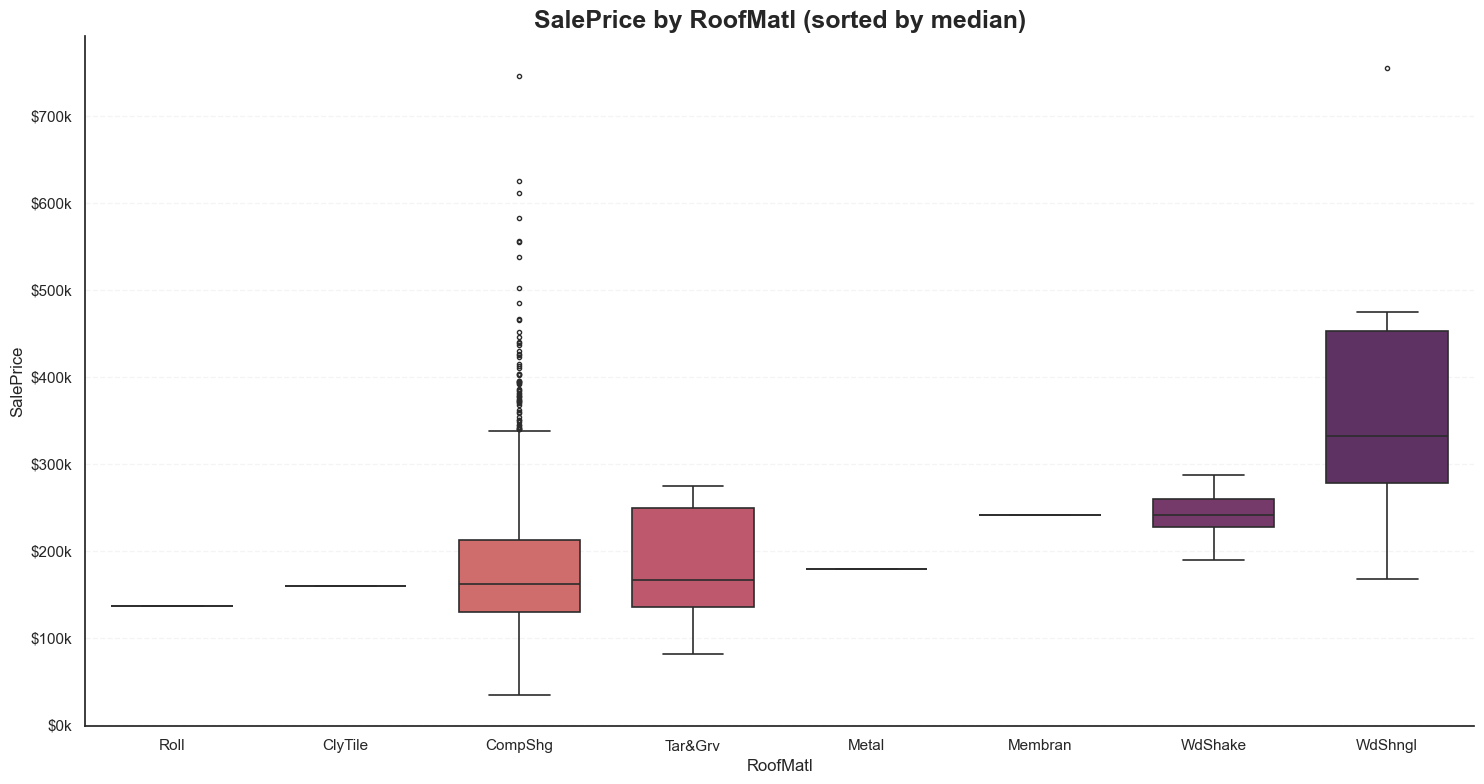

C:\Users\Admin\AppData\Local\Temp\ipykernel_1308\2916846529.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


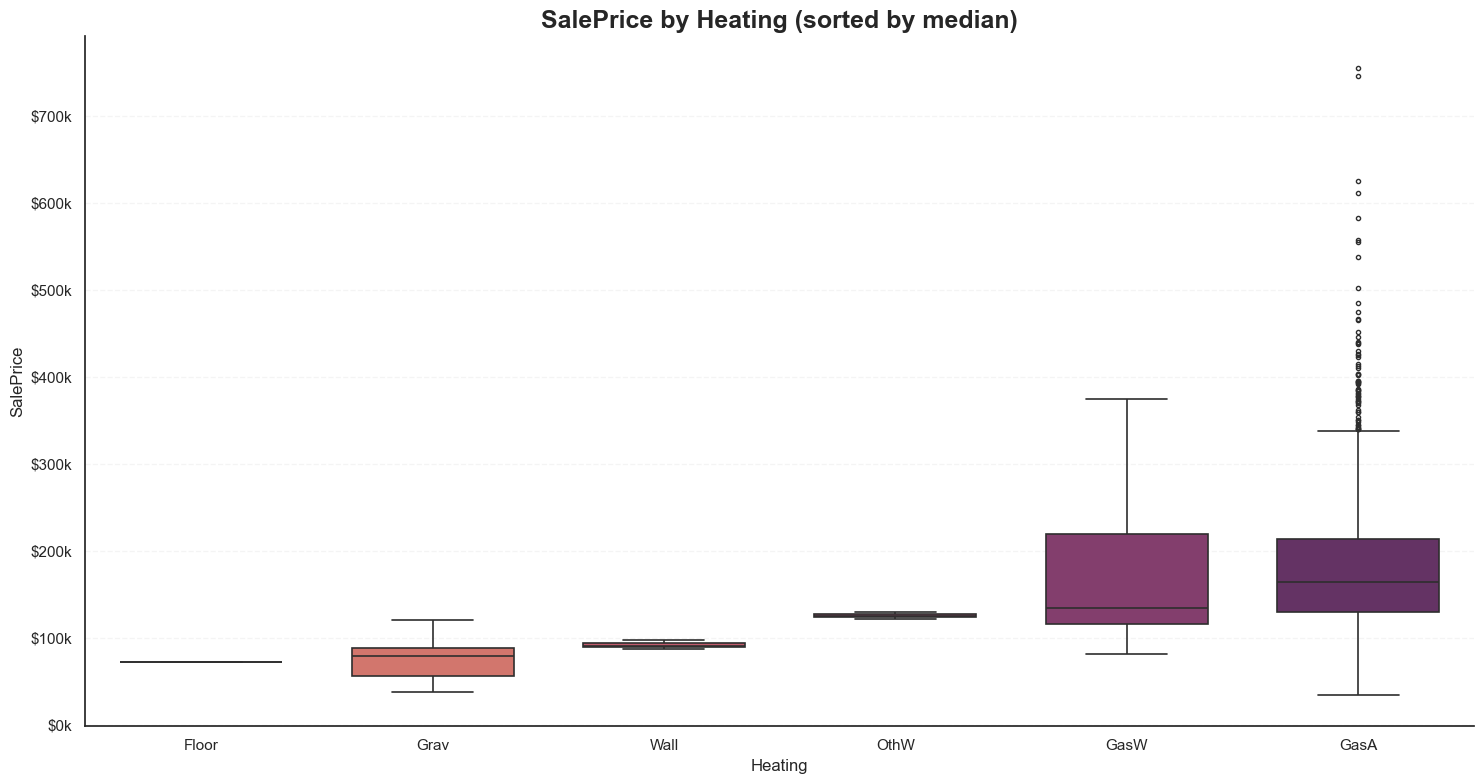

C:\Users\Admin\AppData\Local\Temp\ipykernel_1308\2916846529.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


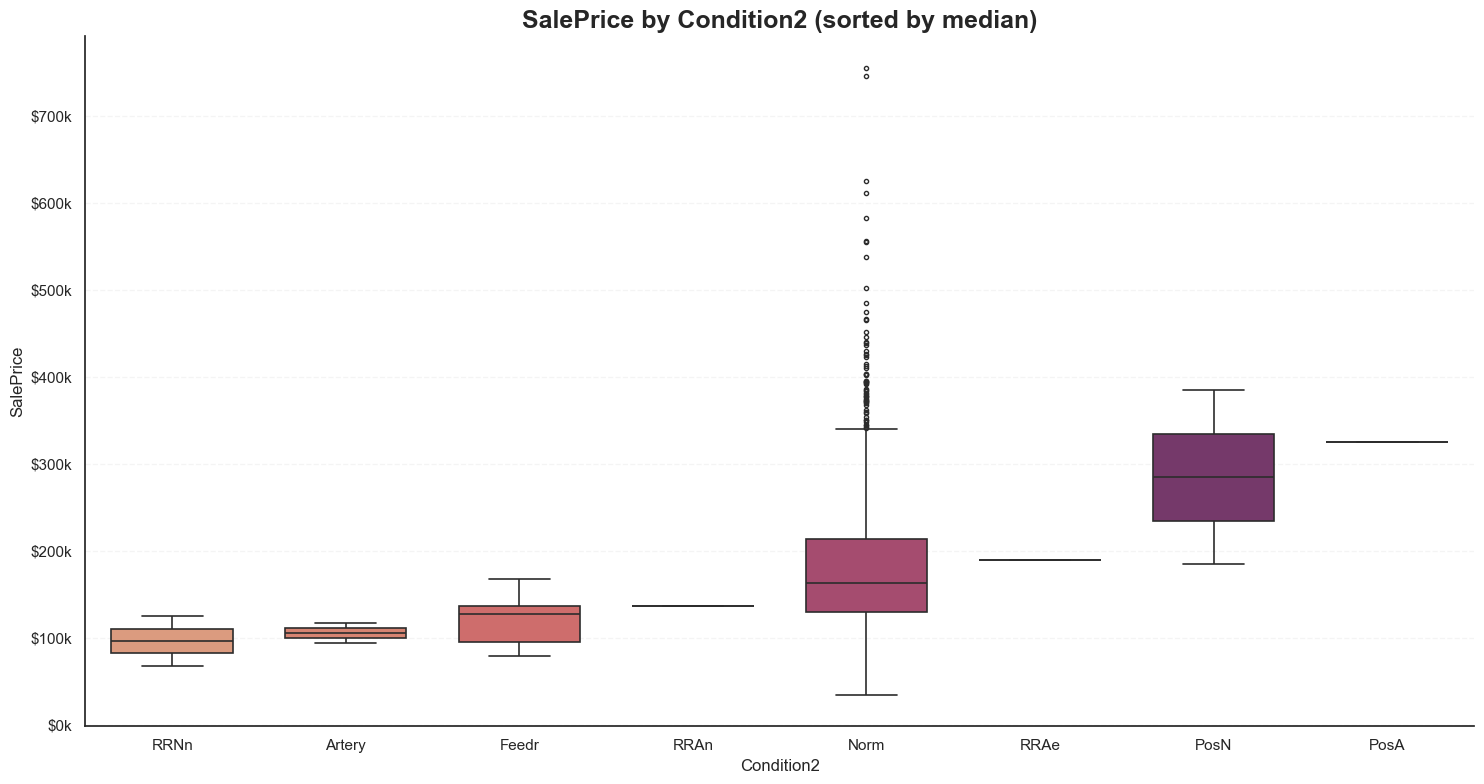

In [12]:
for col in ["RoofMatl", "Heating", "Condition2"]:
    plot_cat_box_sorted(df, col)

## Features to Drop

- `Street` — 99.6% of values are "Pave" with only 2 unique categories. Virtually no variance, so it adds pure noise.
- `Utilities` — 99.9% are "AllPub". Even more skewed than Street. A model can't learn anything useful here.
- `Condition2` — 98.97% are "Norm", but the box plot shows the rare categories (PosN, PosA) have noticeably higher sale prices. However, with so few samples in those rare categories, the model likely can't generalize from them and they risk introducing noise.

## Features to Keep (with caveats)

- `RoofMatl` — 98.2% are "CompShg", yet the box plot reveals meaningful price differentiation — WdShngl and WdShake homes sell for significantly more. We handle the class imbalance (e.g., via binary encoding like "is_premium_roof"), this signal is worth preserving.
- `Heating` — Shows a clear price gradient: Floor/Grav/Wall systems correlate with much lower prices, while GasA/GasW homes are significantly higher. Despite imbalance, this is a genuinely informative feature. Keep with binary or ordinal encoding (e.g., gas vs. non-gas).
- `GarageQual` & `GarageCond` missing values likely tied to homes with no garage. The dominant value "TA" represents 95–96% of non-null values. The missing values are the more interesting signal — they indicate absence of a garage. Keep, but encode missings as a separate "No Garage" category rather than imputing.



# Automated EDA Report (Pandas Profiling)

In [13]:
prof = ProfileReport(df,title="House Price EDA Report",explorative=True,minimal=True)
prof.to_file("../data/external//house_price_eda.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|          | 0/81 [00:00<?, ?it/s]
%|█▏        | 10/81 [00:00<00:01, 56.27it/s]
%|█▉        | 16/81 [00:00<00:01, 32.96it/s]
%|████▉     | 40/81 [00:00<00:00, 82.46it/s]
100%|██████████| 81/81 [00:00<00:00, 118.50it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Preliminary Observations
Now that you are done with your broad overview let's take a look of what you have jot down in notebook so far.

The dataset contains 1460 rows and 80 features. You ascertain that the target variable i.e `SalePrice` exhibits considerable skewness, which will require further investigation. Additionally, several features have a high proportion of missing values and a high number of zeroes, cause high variance. These important results will guide future feature selection and preprocessing. The high number of rows will pose a challenge but with the help of correlation and other statistical tools you should be able to engineer new features and transform columns.

# Univariate Analysis of the Target Variable (SalePrice)
Without wasting any more of your precious time, you fix set your eyes on the prize. It was clear from the prelinimary investigation our primary target i.e. `SalePrice` is skewed and not free of outliers. But this is not enough. You need to justify your name and thus decide to launch thorough interrogation and start dissecting its distribution, skewness, kurtosis and extreme values to not only reveals its true nature but also sets the ground rules for how the remaining features must be treated.

# Distribution of SalePrice
The **Histogram** with **Kernel Density Estimation (KDE)** overlay will show us the overall shape of the distribution. In just a glance it answers whether the target variable follows a normal distribution, presence of right or left skewness. Strong deviation from normality needs to be addressed and
preprocessed for certain models and evaluation metrics.

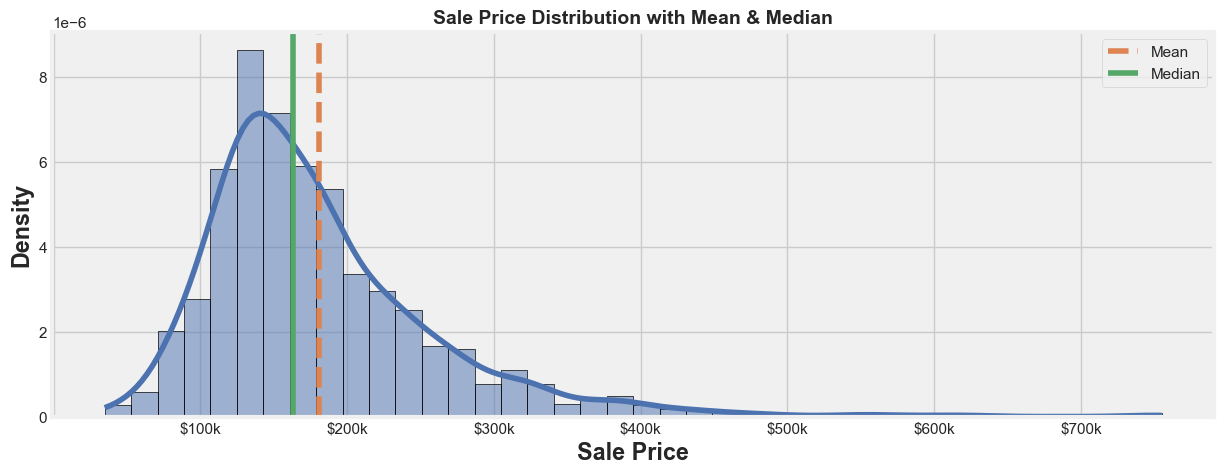

In [14]:
plt.figure(figsize=(15, 5))
plt.style.use('fivethirtyeight')
sns.histplot(df["SalePrice"],bins=40,kde=True,stat="density",edgecolor="black",color="#4C72B0")

plt.axvline(df["SalePrice"].mean(),linestyle="--",label="Mean",color="#DD8452")

plt.axvline(df["SalePrice"].median(),linestyle="-",label="Median",color="#55A868")
ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: "" if x == 0 else f'${int(x/1000)}k'
    )
)

plt.title("Sale Price Distribution with Mean & Median", fontsize=14, fontweight="bold")
plt.xlabel("Sale Price",fontweight='semibold')
plt.ylabel("Density",fontweight='semibold')
plt.legend()

plt.show()


# Boxplot Analysis

We consult with one of the loyal friend of `SalePrice`, Mr.Boxplot who after a gruelling interrogation provides a succinct summary of median price,
Interquartile range (IQR), extreme values and potential outliers. The presence of several high price outliers suggests a long right tail.

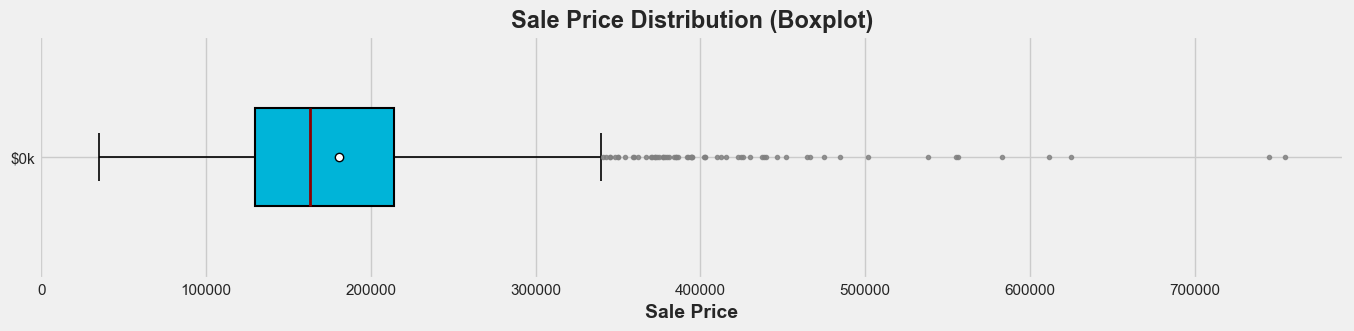

In [15]:

fig, ax = plt.subplots(figsize=(15, 3))

ax.boxplot(df["SalePrice"],vert=False,widths=0.4,patch_artist=True,   showmeans=True,
    boxprops={
        "facecolor": "#00B4D8",
        "edgecolor": "black",
        "linewidth": 1.5
    },
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    medianprops={"color": "darkred", "linewidth": 2},
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 6
    },
    flierprops={
        "marker": ".",
        "markerfacecolor": "gray",
        "markeredgecolor": "gray",
        "alpha": 0.8
    }
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

ax.set_title("Sale Price Distribution (Boxplot)", fontsize=17, fontweight="bold")
ax.set_xlabel("Sale Price",fontsize=14, fontweight='semibold')

plt.show()


# Q–Q Plot (Normality Check)
You continue your quest and then meet the disgruntled relative of `SalePrice`, Mr. Q–Q plot who willingly compares the distribution of `SalePrice` against a theoretical normal distribution. Deviations from the straight line points towards the non normality, heavy tailed behavior and potential benefit of transformations such as log scaling. During your conversation it is mentioned there was once a psyciatric evaluation of the target and you get your hands on Sorted `SalePrice` values **(Outlier Inspection)** which visually showed the growth pattern, sudden jumps and whether outliers form a small minority or a gradual tail this visualization is the final nail in the coffin  that the dataset contains high value estates that may disproportionately influence model training.

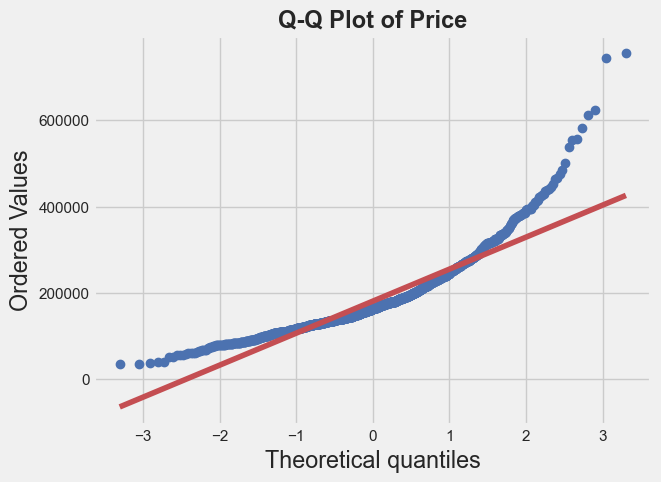

In [16]:
stats.probplot(df["SalePrice"], plot=plt)
plt.title("Q-Q Plot of Price",fontsize=17, fontweight="bold")
plt.show()

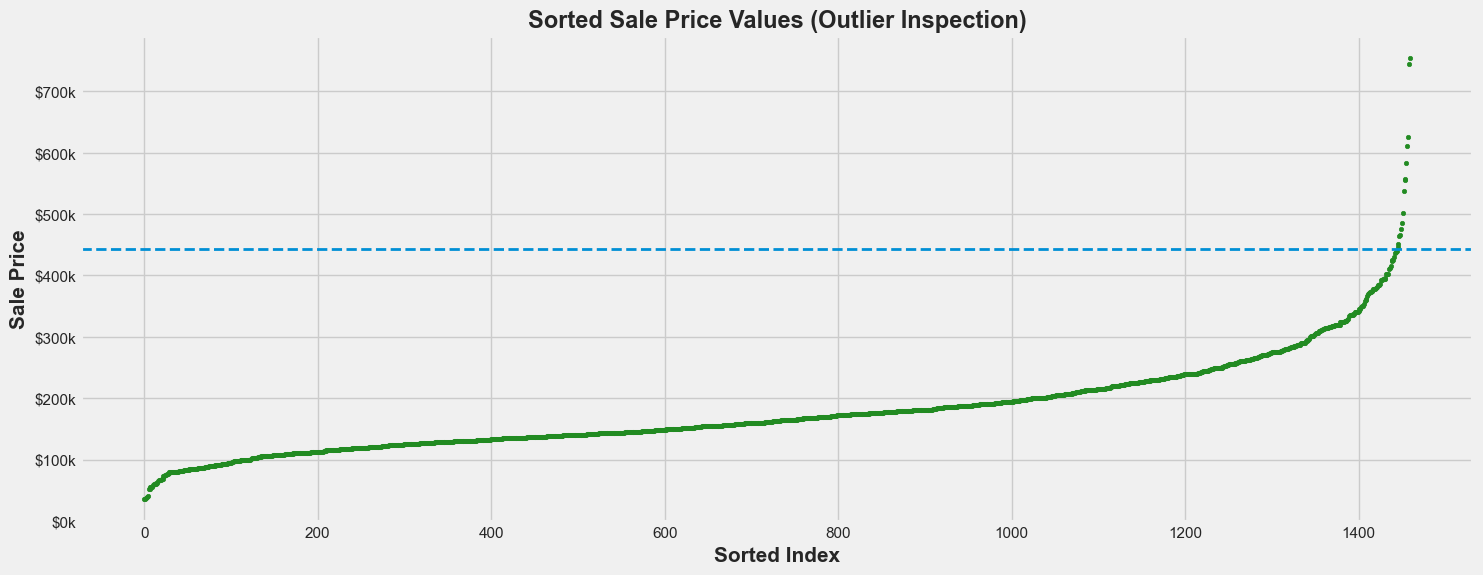

In [17]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(range(df.shape[0]),np.sort(df["SalePrice"].values),s=10,color="forestgreen")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
threshold = np.percentile(df["SalePrice"], 99)
ax.axhline(threshold, linestyle="--", linewidth=2)

ax.set_xlabel("Sorted Index", fontsize=15,fontweight='semibold')
ax.set_ylabel("Sale Price", fontsize=15,fontweight='semibold')
ax.set_title("Sorted Sale Price Values (Outlier Inspection)",fontsize=17,fontweight="bold")

plt.show()


# Statistical Summary of SalePrice
Finally, we conclude our research with statistical measures to quantify our observations.

    Skewness: Measures asymmetry in the distribution
    
    Kurtosis: Indicates tail heaviness and presence of extreme values

A high positive skew and kurtosis further reinforce the need for potential transformations during preprocessing.

In [18]:
print("Skewness: %f" % df['SalePrice'].skew())
print("Kurtosis: %f" % df['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


# Missing Values Analysis

As you proceed the case gets more intresting. A lot of data seems to have disapperaed into thin air. Since you need all the pieces to put together the puzzle you are left with no other choice but to investigate these disappearances. Before any concrete steps can be taken, the first order of business is to examine the scope of the missing data. Then we will answer where did the data go, whether the data is  **Missing Completely At Random (MCAR)** or **Missing Not at Random (MNAR)** or is it a completley diffrent story. Only by understanding who is missing and how much can we decide whether to recover these lost clues, reinterpret their absence, or exclude them from the case altogether

# Percentage of Missing Values per Feature
The following table shows the percentage of missing values in each feature. This helps us understand relative severity independent of dataset size.

In [19]:
mean_null_df = pd.DataFrame(np.round(df.isnull().mean()*100,2),columns=["null_percent"])
mean_null_df = mean_null_df[mean_null_df["null_percent"] != 0]
mean_null_df.sort_values(by = ['null_percent'],ascending= False)

,null_percent
PoolQC,99.52
MiscFeature,96.30
Alley,93.77
Fence,80.75
MasVnrType,59.73
FireplaceQu,47.26
LotFrontage,17.74
GarageType,5.55
GarageYrBlt,5.55
GarageFinish,5.55


# Absolute Count of Missing Values

To get a better picture you take out your cutting edge visualization tool and plot a bar chart which tells the number of missing values per feature, helping us spot problematic columns at a glance. The bar plot clearly highlights features with a disproportionately high number of missing values. 

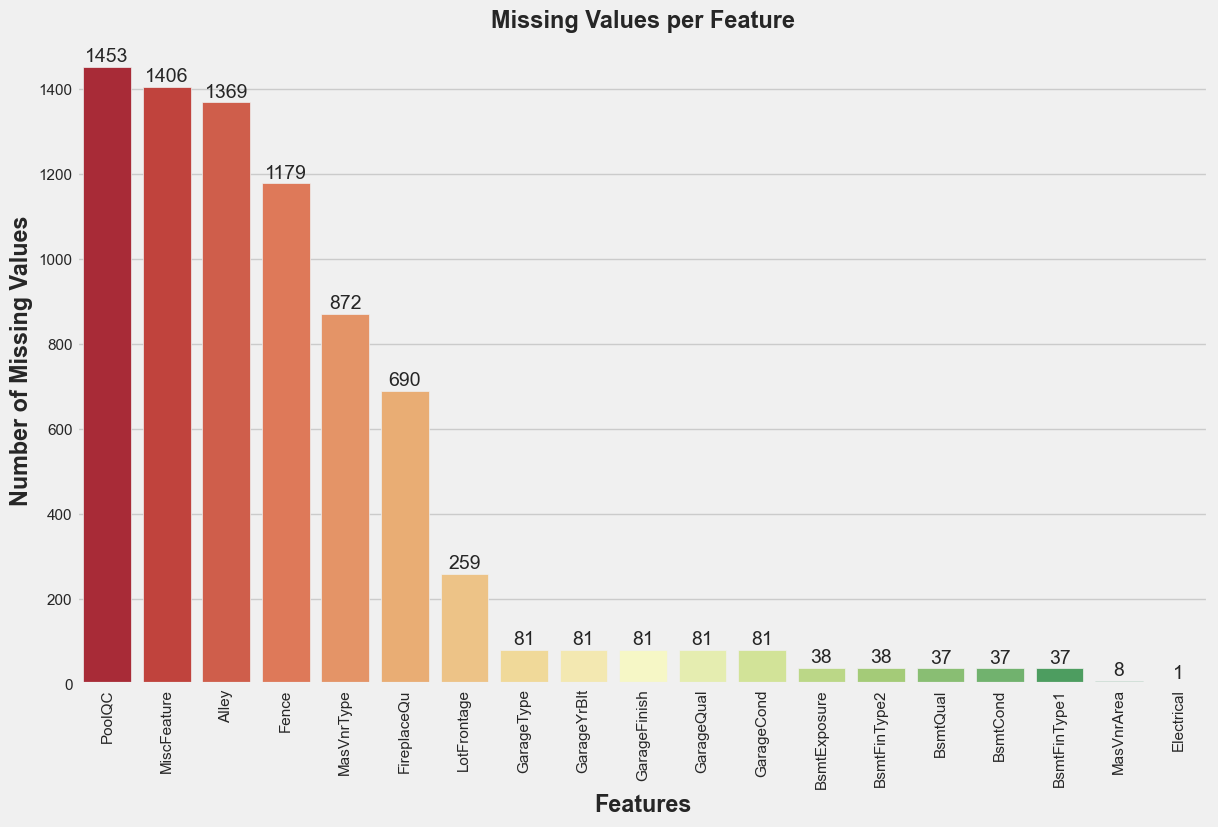

In [20]:
null_df = pd.DataFrame(df.isnull().sum(),columns=["null_count"])
null_df = null_df[null_df["null_count"] != 0]
null_df = null_df.reset_index()
null_df.columns = ["feature", "null_count"]
null_df = null_df.sort_values(by="null_count", ascending=False)

plt.subplots(figsize=(13,8))

ax = sns.barplot(x="feature",y="null_count",hue="feature",data=null_df,palette="RdYlGn",legend=False)

plt.xticks(rotation=90)

ax.set_title("Missing Values per Feature", fontsize=17,fontweight="bold")

ax.set_xlabel("Features",fontweight='semibold')

ax.set_ylabel("Number of Missing Values",fontweight='semibold')

for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x() + p.get_width() / 2, p.get_height() + 2),ha="center",va="bottom")

plt.show()

As you look closer something doesn't feel right. You start to read up about what all you have been given abouth the featues in the description text which was part of the prelinamary discovery you were given. You realize that what appears as missing data in the case of categorical value is, in fact, meaningful absence. This changes everything. A NaN value does not indicate lost information, but rather the absence of a particular amenity altogether. Since leaving them as NaN would hurt your analysis you decide to handle them early on.

Before you got carried away four features caught your eye, `MasVnrArea`, `LotFrontage`, `GarageYrBlt`, `LotFrontage` and `Electrical`. They tried to hide in plain sight but of course you noticed them right away. These features do not naturally encode absence and and therefore warrant closer inspection.

- `MasVnrArea`: It does not represent any amenity and might very well indicate missing information rather than the absence of masonry veneer therfore you need to cross check it with `MasVnrType` whether null values correspond to “No Masonry Veneer” or genuinely missing data.
    
- `LotFrontage`: Similary to `MasVnrArea` this feature does not represent any amenity, nowhere in the data description is a missing LotFrontage value described as representing absence and thus it most likely represents a lapse in data information or unrecorded measurements. They contain a significant proportion of missing values (~17%), which makes row wise deletion impractical, as it would result in substantial information loss. To preserve data integrity while maintaining realistic values, missing LotFrontage might be dealt with KNN Imputation, Median Imputaion,Random Imputation or any of the many options available.
    
- `GarageYrBlt`: Like MasVnrArea this feature is not an amenity. A missing value may either point towards the absence of a garage or missing construction year information and  there before imputing it we need to examine it in conjunction with `GarageType`.

- `Electrical`: feature has a very small percentage of missing values. Given their negligible proportion, imputing these entries would add little value while introducing assumptions. Therefore, dropping the concerned rows is a quick, effective, and low risk approach that does not significantly impact the dataset.
    


In [21]:
df[df["MasVnrArea"].isnull() & df["MasVnrType"].notnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


Now you can safely say `MasVnrArea` null values occur in conjunction with `MasVnrType` = "None" and therefore correctly indicate the absence of masonry veneer. These motivates us impute these values in a way that preserves the nature

In [22]:
df[df["GarageYrBlt"].isnull() & df["GarageType"].notnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


The above check left no doubt in your mind that `GarageYrBuilt` missing values are in conjunction with `GarageType` = "None" and thus rightfully indicate the absence of a garage. We safely impute it in such a way to preserve the nature of the feature while marking the absence of garage.

# Outlier Detection

Now it is time to deal with the outlaws. These data points sometime tends to be erroneous and can negatively impact our model. You crack your knucles and buck up to analyze them. Some might be off beam and require removal, others might be perfectly legitmate extreme cases and a few might even tell us something useful. You get to work to first create a DataFrame to gauge the extent of outliers in each feature.

In [23]:
def outlier_summary_iqr(df, numeric_cols=None):
    
    """Returns a DataFrame with outlier count and percentage for each numeric column using the IQR method."""
    
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include="number").columns

    outlier_summary = []

    for col in numeric_cols:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        if IQR == 0:
            outlier_count = 0
        else:
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

        outlier_summary.append({"feature": col,"outlier_count": outlier_count,"outlier_percent": round((outlier_count / len(df)) * 100, 2)})

    return (pd.DataFrame(outlier_summary).sort_values("outlier_percent", ascending=False).reset_index(drop=True))



As a rule of thumb, you know a few oddballs are expected here and there. However when the percentage becomes more than 5% then it becomes a strong signal for deeper investigation. With this insight you isolate them and commence.

In [24]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
outliers = outlier_summary_iqr(df,num_cols)
outliers = outliers[outliers["outlier_count"] != 0]
outliers

,feature,outlier_count,outlier_percent
0,OverallCond,125,8.56
1,MSSubClass,103,7.05
2,MasVnrArea,96,6.58
3,LotFrontage,88,6.03
4,OpenPorchSF,77,5.27
5,LotArea,69,4.73
6,SalePrice,61,4.18
7,TotalBsmtSF,61,4.18
8,BedroomAbvGr,35,2.40
9,WoodDeckSF,32,2.19


In [25]:
outliers[outliers['outlier_percent'] > 5]

,feature,outlier_count,outlier_percent
0,OverallCond,125,8.56
1,MSSubClass,103,7.05
2,MasVnrArea,96,6.58
3,LotFrontage,88,6.03
4,OpenPorchSF,77,5.27


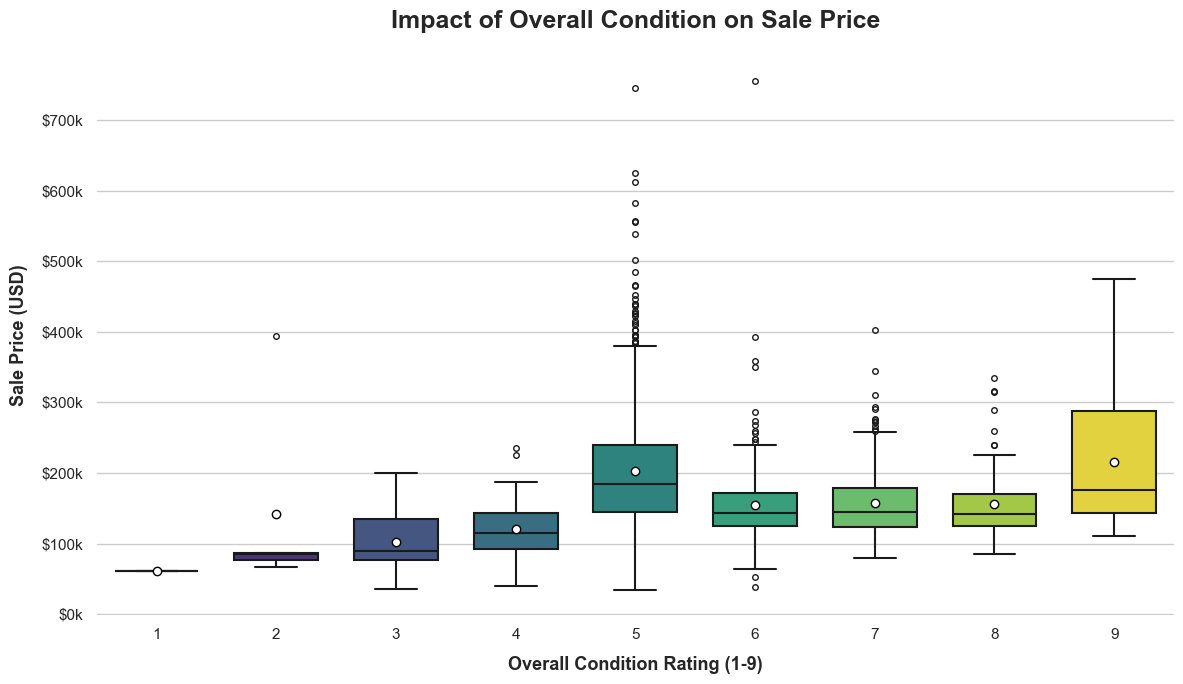

In [26]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

ax = sns.boxplot(x="OverallCond", y="SalePrice", data=df, hue="OverallCond",palette="viridis",linewidth=1.5,fliersize=4,width=0.7,legend=False,showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})

plt.title("Impact of Overall Condition on Sale Price", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Overall Condition Rating (1-9)", fontsize=13, labelpad=10,fontweight='semibold')
plt.ylabel("Sale Price (USD)", fontsize=13, labelpad=10,fontweight='semibold')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
sns.despine(left=True,bottom=True)
plt.tight_layout()
plt.show()

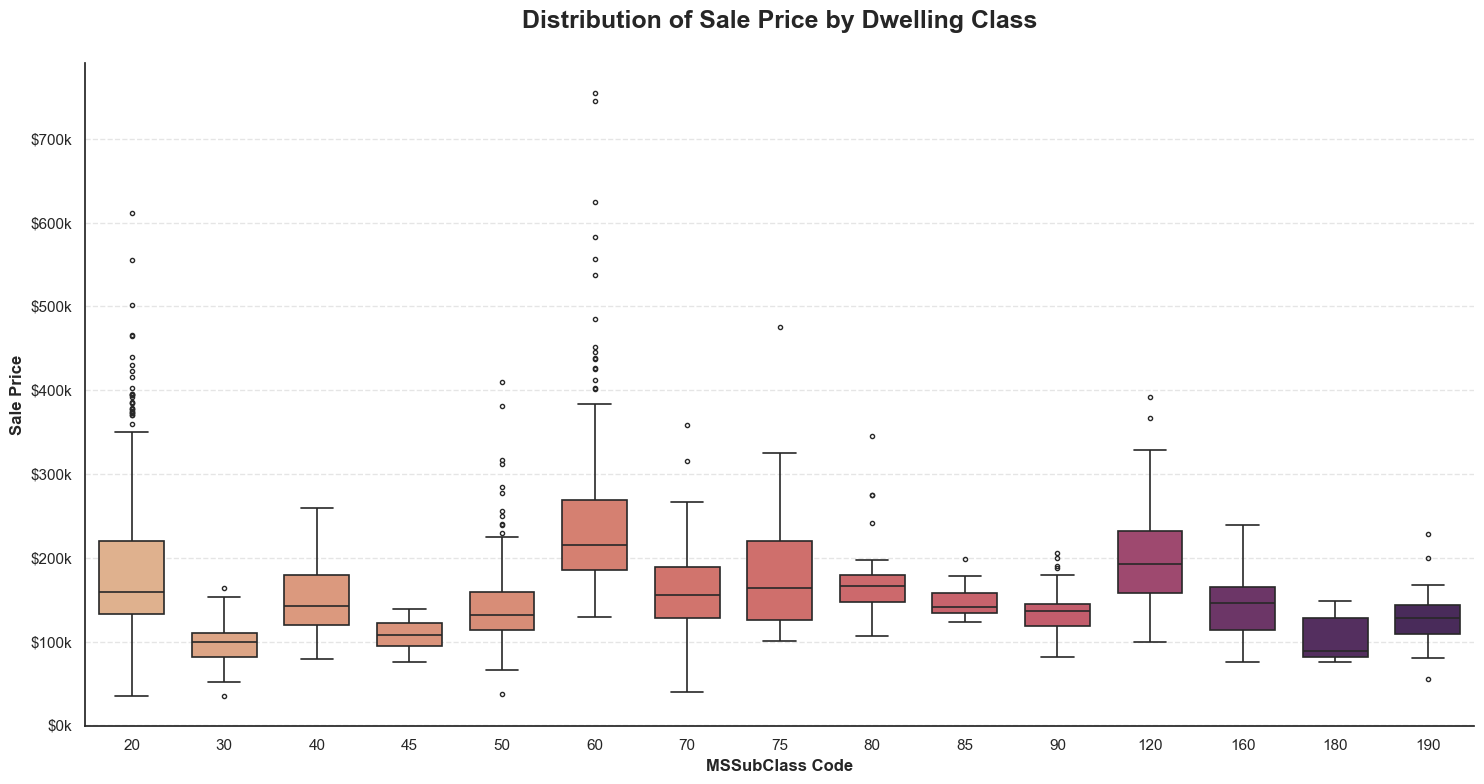

In [27]:
sns.set_theme(style="white")
plt.figure(figsize=(15, 8))

ax = sns.boxplot(x="MSSubClass", y="SalePrice", data=df, hue="MSSubClass",palette="flare",linewidth=1.2,fliersize=3,width=0.7,legend=False)

plt.title("Distribution of Sale Price by Dwelling Class", fontsize=18, fontweight='bold', pad=25)
plt.xlabel("MSSubClass Code", fontsize=12, fontweight='semibold')
plt.ylabel("Sale Price", fontsize=12, fontweight='semibold')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
sns.despine()

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.2)

plt.tight_layout()
plt.show()


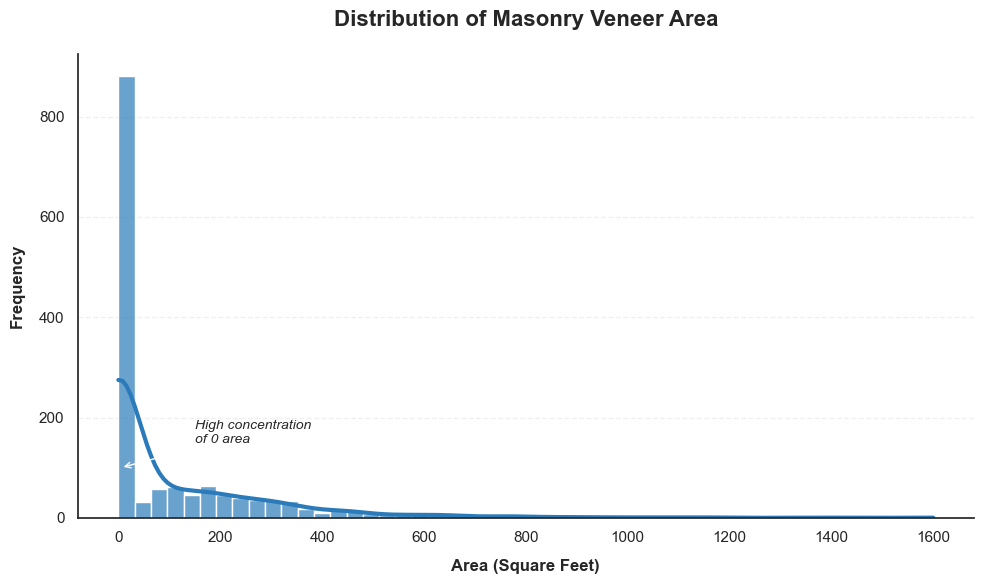

In [28]:
sns.set_theme(style="white") 
plt.figure(figsize=(10, 6))

ax = sns.histplot(df["MasVnrArea"], bins=50, kde=True,color="#2b7bba",edgecolor="white",line_kws={"linewidth": 3},alpha=0.7                )

plt.title("Distribution of Masonry Veneer Area", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12, labelpad=10,fontweight='semibold')
plt.ylabel("Frequency", fontsize=12, labelpad=10,fontweight='semibold')

sns.despine() 

ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.annotate('High concentration\nof 0 area',xy=(5, 100), xytext=(150, 150),arrowprops=dict(facecolor='black', arrowstyle='->'),fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()


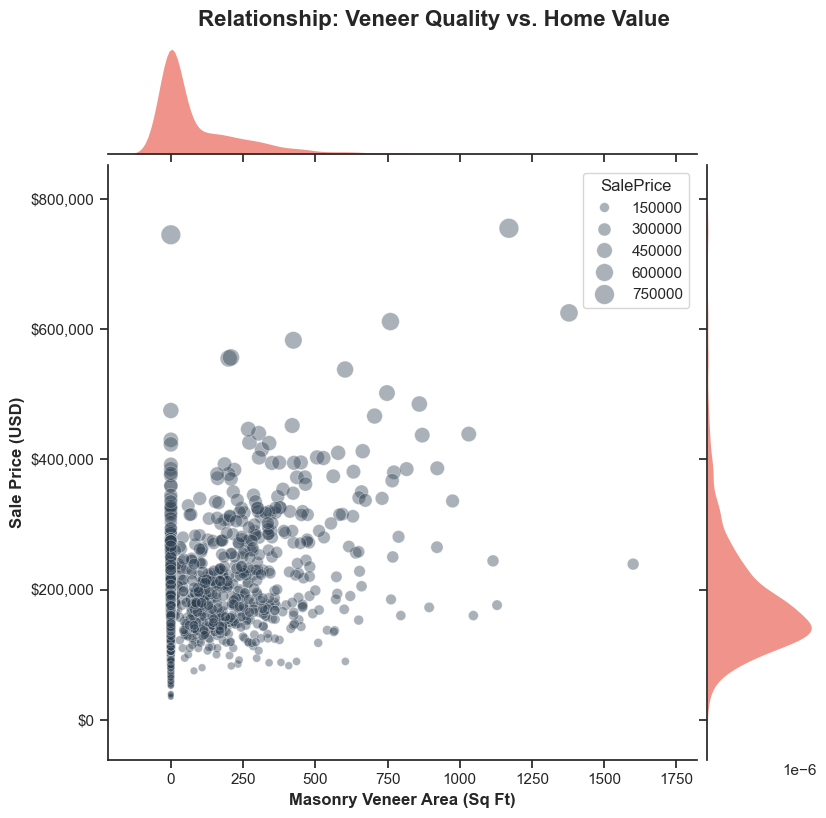

In [29]:
sns.set_theme(style="ticks")
g = sns.JointGrid(data=df, x="MasVnrArea", y="SalePrice", space=0.1, height=8)

g.plot_joint(sns.scatterplot,size=df["SalePrice"],sizes=(20, 200),alpha=0.4, color="#2c3e50",edgecolor="white",linewidth=0.5)
g.plot_marginals(sns.kdeplot, fill=True, color="#e74c3c", alpha=0.6, linewidth=0)

g.ax_joint.set_xlabel("Masonry Veneer Area (Sq Ft)", fontsize=12, fontweight='bold')
g.ax_joint.set_ylabel("Sale Price (USD)", fontsize=12, fontweight='bold')

g.ax_joint.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

g.fig.suptitle("Relationship: Veneer Quality vs. Home Value", fontsize=16, fontweight='bold', y=1.02)

plt.show()


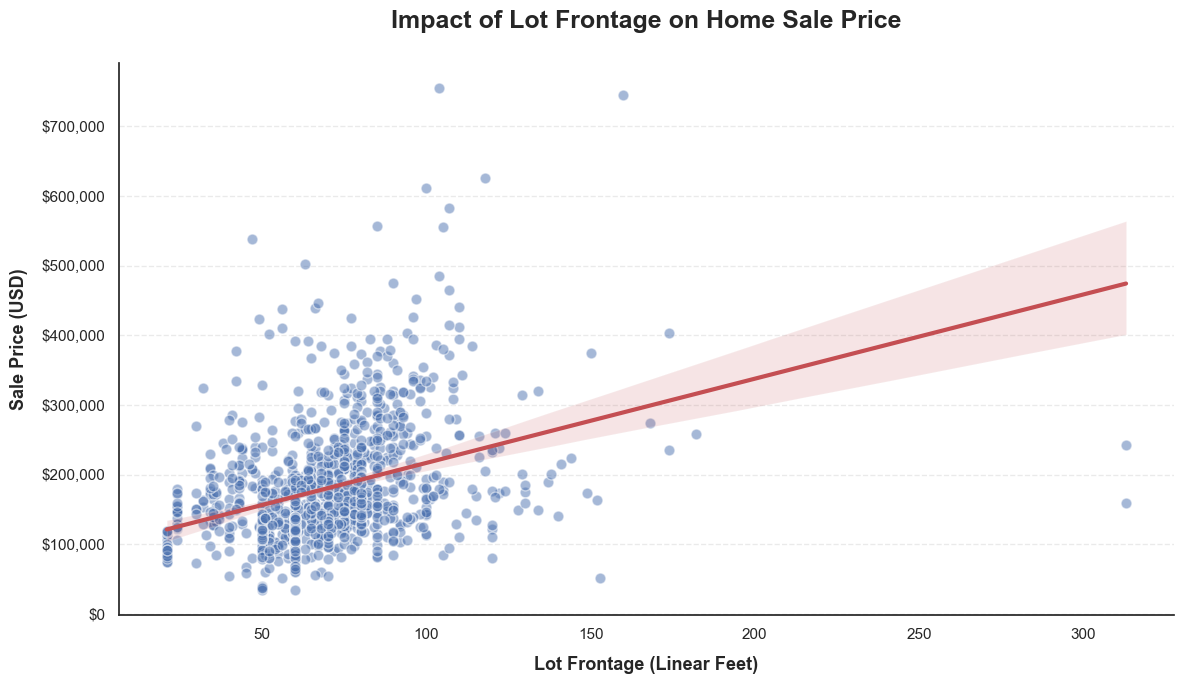

In [30]:
sns.set_theme(style="white", palette="muted")
plt.figure(figsize=(12, 7))

ax = sns.regplot(x="LotFrontage", y="SalePrice", data=df,
    scatter_kws={
        's': 60,              
        'alpha': 0.5,         
        'edgecolor': 'white',
        'color': '#4c72b0'    
    },
    line_kws={
        'color': '#c44e52',   
        'lw': 3               
    }
)

plt.title("Impact of Lot Frontage on Home Sale Price", fontsize=18, fontweight='bold', pad=25)
plt.xlabel("Lot Frontage (Linear Feet)", fontsize=13, labelpad=10,fontweight='semibold')
plt.ylabel("Sale Price (USD)", fontsize=13, labelpad=10,fontweight='semibold')

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4) 
plt.tight_layout()

plt.show()


`OverallCond` showed ~8.5% outliers but visual analysis indicates that these values correspond to valid high priced  properties rather than anomalies. Therefore, OverallCond outliers will be retained and the feature treated as ordinal rather than numeric for model.

Similar to `OverallCond` feature `MSSubClass` showed a high percentage i.e. ~7% outliers using the IQR method, but visual analysis revealed that MSSubClass represents categorical rather than a continuous variable. The observed extreme SalePrice values correspond to genuinely expensive housing categories (e.g., newer 2-story and PUD homes). Therefore, MSSubClass was treated as a categorical feature, and no outlier removal should applied.

`MasVnrArea` exhibits a zero inflated and highly right skewed distribution, with a large proportion of properties having no masonry veneer. Zero values represent the absence of veneer rather than missing data. To capture both the presence and magnitude of masonry veneer, a binary indicator feature will be created alongside a transformed continuous feature. No outlier removal will be applied, as extreme values correspond to valid high end properties.

`MasVnrArea` has a high number of zeroes and a  right skewed distribution with the majority of properties having no masonry veneer. Scatter analysis against `SalePrice` shows a positive association for non zero values, with outliers in conjunction with valid high end properties. Although the IQR showed ~6.7% of values as outliers, visual inspection confirms these points represent valid premium homes. Therefore, no outlier removal is to be applied. Instead, a binary indicator for veneer presence and a log transformed feature would be more fruitful for modeling.

`LotFrontage` shows a weak but positive relationship with `SalePrice` and a right skewed distribution with a small number of large frontage values. Visual analysis proves that these high values correspond to valid premium properties rather than anomalies.

# Aggregated Outlier Flagging

Just before you were finished you still had one trick up you sleeve. To identify potentially eorrneous data points, rows were ranked based on the number of features in which they were flagged as outliers. This allowed targeted manual inspection of highly extreme observations, rather than indiscriminate removal.

In [31]:
def get_outlier_rows(df, cols, min_flags=2):
    """
    Returns a DataFrame of rows flagged as outliers
    in at least `min_flags` number of features.
    """

    outlier_flags = pd.DataFrame(index=df.index)

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_flags[col] = ((df[col] < lower) | (df[col] > upper)).astype(int)

    outlier_flags["outlier_count"] = outlier_flags.sum(axis=1)

    outlier_df = df.loc[outlier_flags["outlier_count"] >= min_flags].copy()
    outlier_df["outlier_count"] = outlier_flags.loc[outlier_df.index, "outlier_count"]

    outlier_df = outlier_df.sort_values("outlier_count", ascending=False)

    return outlier_df, outlier_flags


In [32]:
col=outliers['feature'].to_list()
outlier_df,outlier_flags = get_outlier_rows(df,col,min_flags=4)
outlier_df[["outlier_count", "SalePrice"] + col].head(15)

,outlier_count,SalePrice,OverallCond,MSSubClass,MasVnrArea,LotFrontage,OpenPorchSF,LotArea,SalePrice,TotalBsmtSF,...,BsmtUnfSF,GarageArea,1stFlrSF,YearBuilt,BsmtFinSF1,Fireplaces,GarageCars,OverallQual,2ndFlrSF,BsmtFullBath
1298,11,160000,5,60,796.0,313.0,292,63887,160000,6110,...,466,1418,4692,2008,5644,3,2,10,950,2
523,9,184750,5,60,762.0,130.0,406,40094,184750,3138,...,878,884,3138,2007,2260,1,3,10,1538,1
1182,7,745000,5,60,0.0,160.0,78,15623,745000,2396,...,300,813,2411,1996,2096,2,3,10,2065,1
691,7,755000,6,60,1170.0,104.0,50,21535,755000,2444,...,989,832,2444,1994,1455,2,3,10,1872,0
898,6,611657,5,20,760.0,100.0,67,12919,611657,2330,...,142,820,2364,2009,2188,2,3,9,0,1
178,6,501837,5,20,748.0,63.0,60,17423,501837,2216,...,312,1166,2234,2008,1904,1,3,9,0,1
1268,6,381000,9,50,632.0,NaN,12,14100,381000,728,...,536,1014,1968,1935,192,2,3,8,1479,0
769,6,538000,5,60,603.0,47.0,36,53504,538000,1650,...,234,841,1690,2003,1416,1,3,8,1589,1
803,6,582933,5,60,424.0,107.0,170,13891,582933,1734,...,1734,1020,1734,2008,0,1,3,9,1088,0
185,6,475000,9,75,0.0,90.0,260,22950,475000,1107,...,1107,840,1518,1892,0,2,3,10,1518,0


In [33]:
bad_idx = [523, 1298]
df.loc[bad_idx]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


# Feature Relationships and Correlation Analysis

Correlation analysis revealed several strong predictors of `SalePrice`, including `OverallQual`, `GrLivArea`, basement size, and garage capacity. While multiple feature groups exhibited high intercorrelation, no features were removed at this stage, as tree-based models are robust to multicollinearity. Feature selection was deferred to the modeling phase using feature importance and regularization techniques.

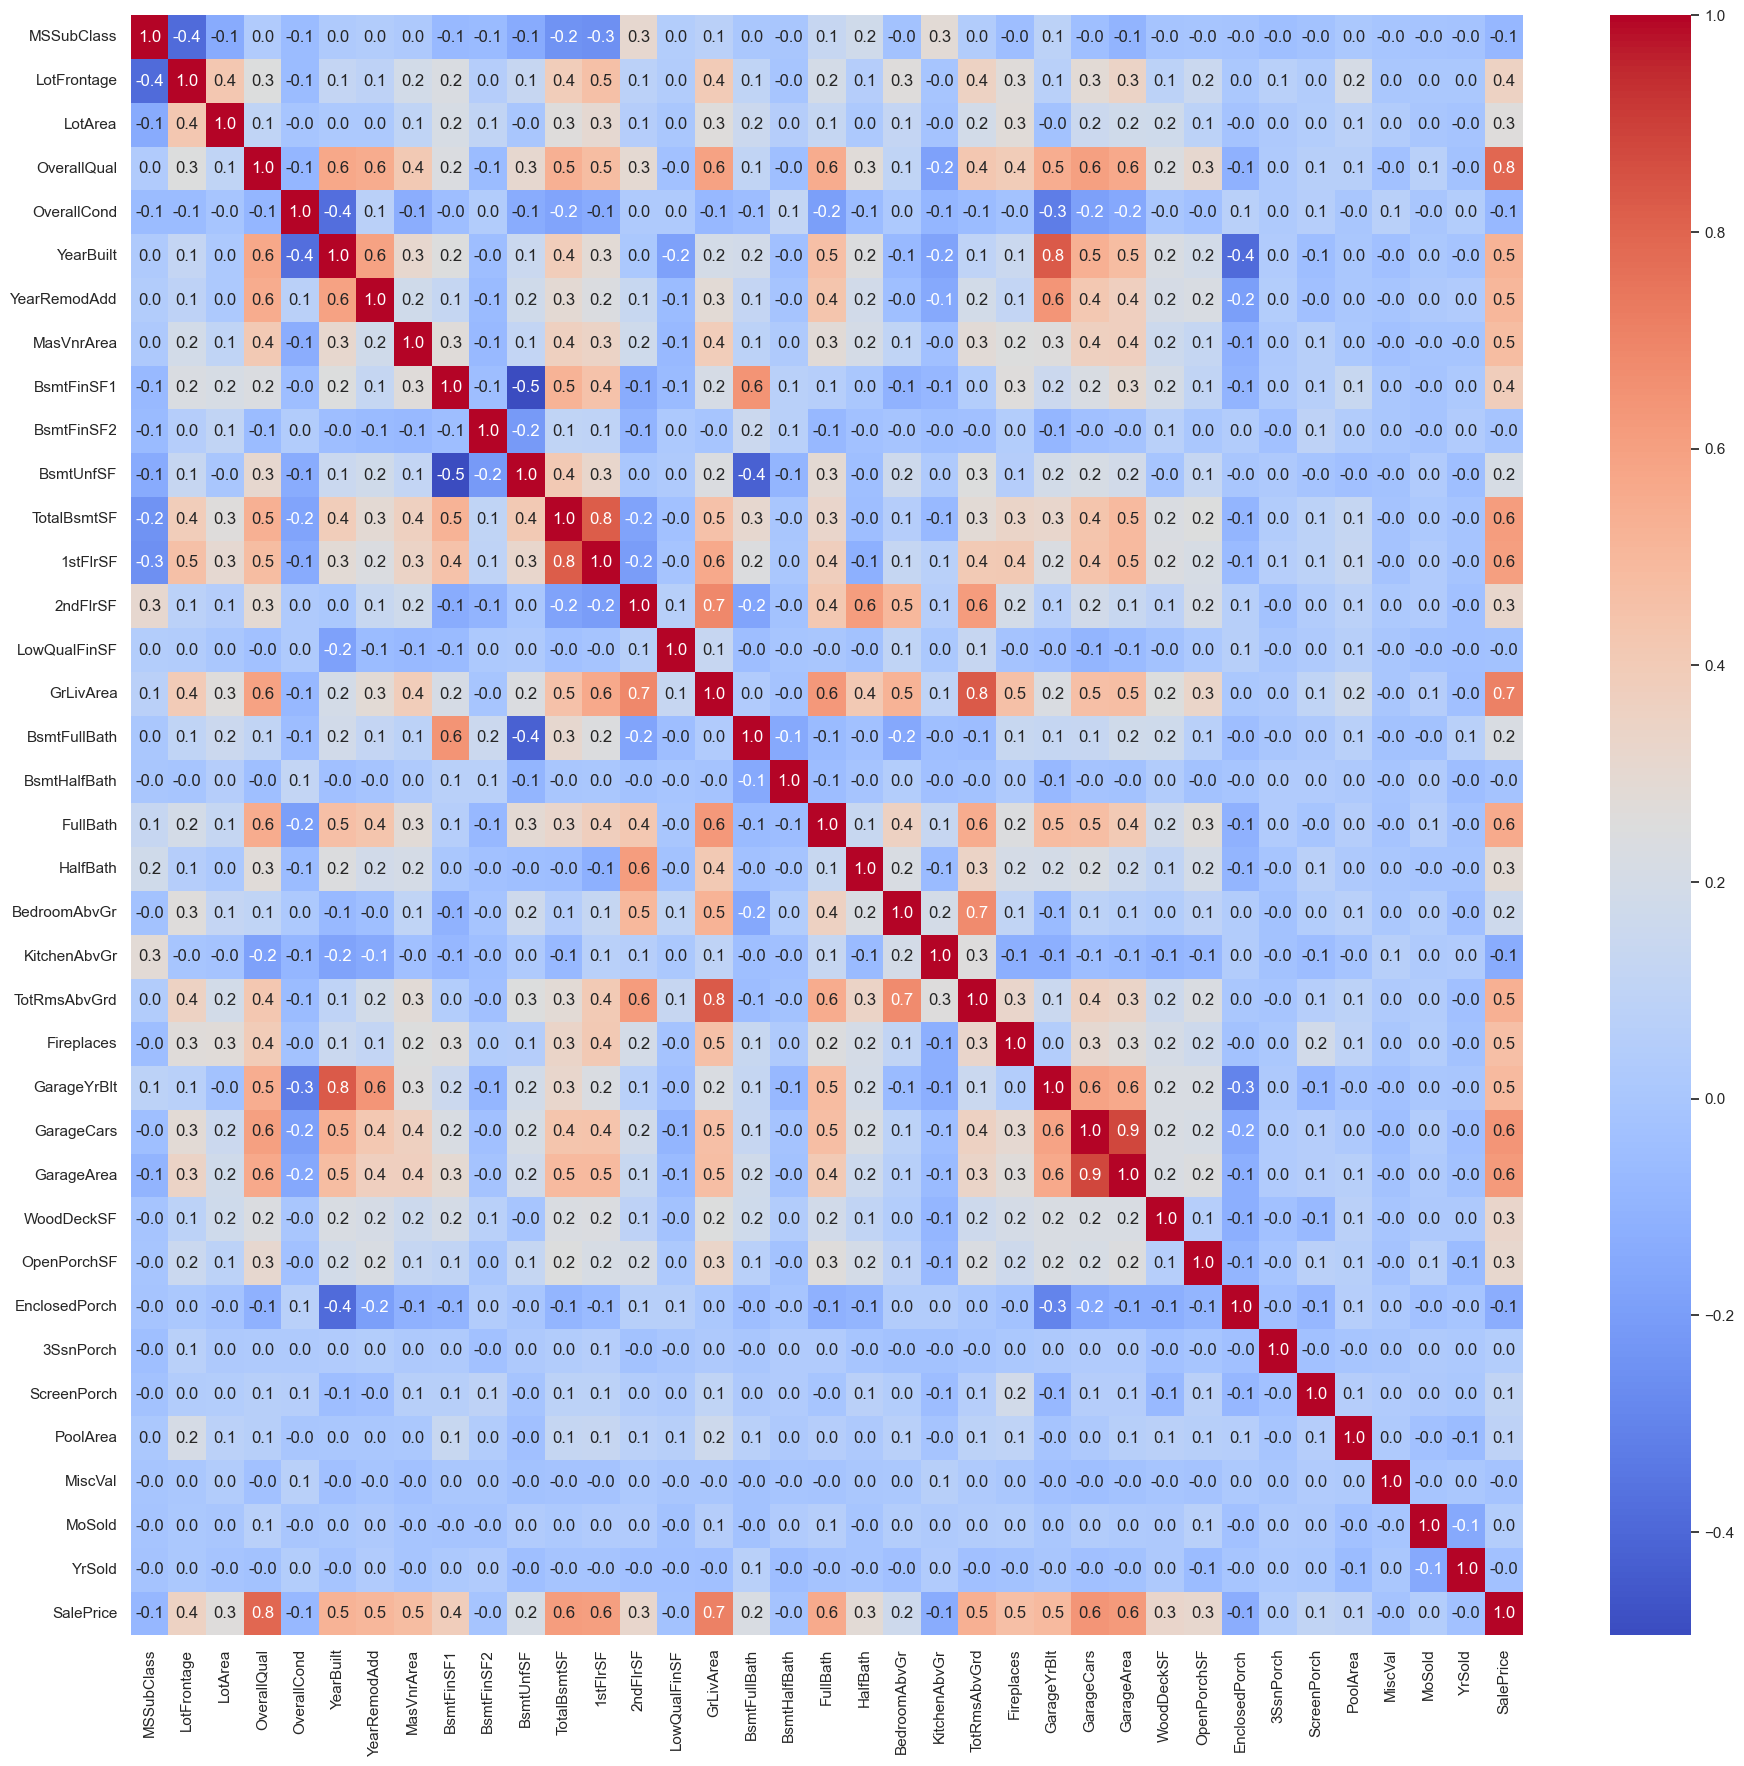

In [34]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(20,20))
sns.heatmap(numeric_df.drop(columns = ["Id"]).corr(),annot=True,fmt='.1f',cmap="coolwarm")
plt.show()

After examining the **Pearson Correlation** structure among numerical features and the target variable to assess linear dependencies and detect multicollinearity. Strong correlations with SalePrice are observed for quality and size related attributes, confirming their dominant influence on house prices. Several feature pairs display high inter correlation, suggesting redundant information and justifying the use of regularization and ensemble based models to mitigate multicollinearity effects.